In [1]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/sdtools"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/general_functions"))

from heatflux_functions import * 

from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
plt.style.use('default')
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


In [2]:


def replace_guards(var):
    """
	This in-place replaces the points in the guard cells with the points on the boundary
    
    """
    # Strip the edge guard cells
    var = var[1:-1]

    var[0] = 0.5*(var[0] + var[1])
    var[-1] = 0.5*(var[-1] + var[-2])
    return var

In [3]:

alpha_vals = [-1, 0.2, 0.06]
neon_vals = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
parent_dir = '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/updated_flux_limitation/2025-04_single_core_production'


cs = dict()


for alpha in alpha_vals:
    for neon in neon_vals:
        name = f"alpha_{alpha}_neon_{neon}"
        print(f"Loading {name}")
        cs[name] = Load.case_1D(f'{parent_dir}/alpha_{alpha}/neon_{neon}', guard_replace = False, use_squash=True)


Loading alpha_-1_neon_0.0
- Looking for squash file
- Squash file found. squash date 04/10/2025, 12:01:46, dmp file date 04/09/2025, 18:51:54
Skipping unnormalisation
Loading alpha_-1_neon_0.01
- Looking for squash file
- Squash file found. squash date 04/10/2025, 12:02:09, dmp file date 04/09/2025, 19:38:34
Skipping unnormalisation
Loading alpha_-1_neon_0.02
- Looking for squash file
- Squash file found. squash date 04/10/2025, 12:02:40, dmp file date 04/09/2025, 20:49:21
Skipping unnormalisation
Loading alpha_-1_neon_0.03
- Looking for squash file
- Squash file found. squash date 04/10/2025, 12:03:04, dmp file date 04/09/2025, 22:04:49
Skipping unnormalisation
Loading alpha_-1_neon_0.04
- Looking for squash file
- Squash file found. squash date 04/10/2025, 12:03:25, dmp file date 04/09/2025, 23:35:15
Skipping unnormalisation
Loading alpha_-1_neon_0.05
- Looking for squash file
- Squash file found. squash date 04/10/2025, 12:03:44, dmp file date 04/10/2025, 01:29:24
Skipping unnormali

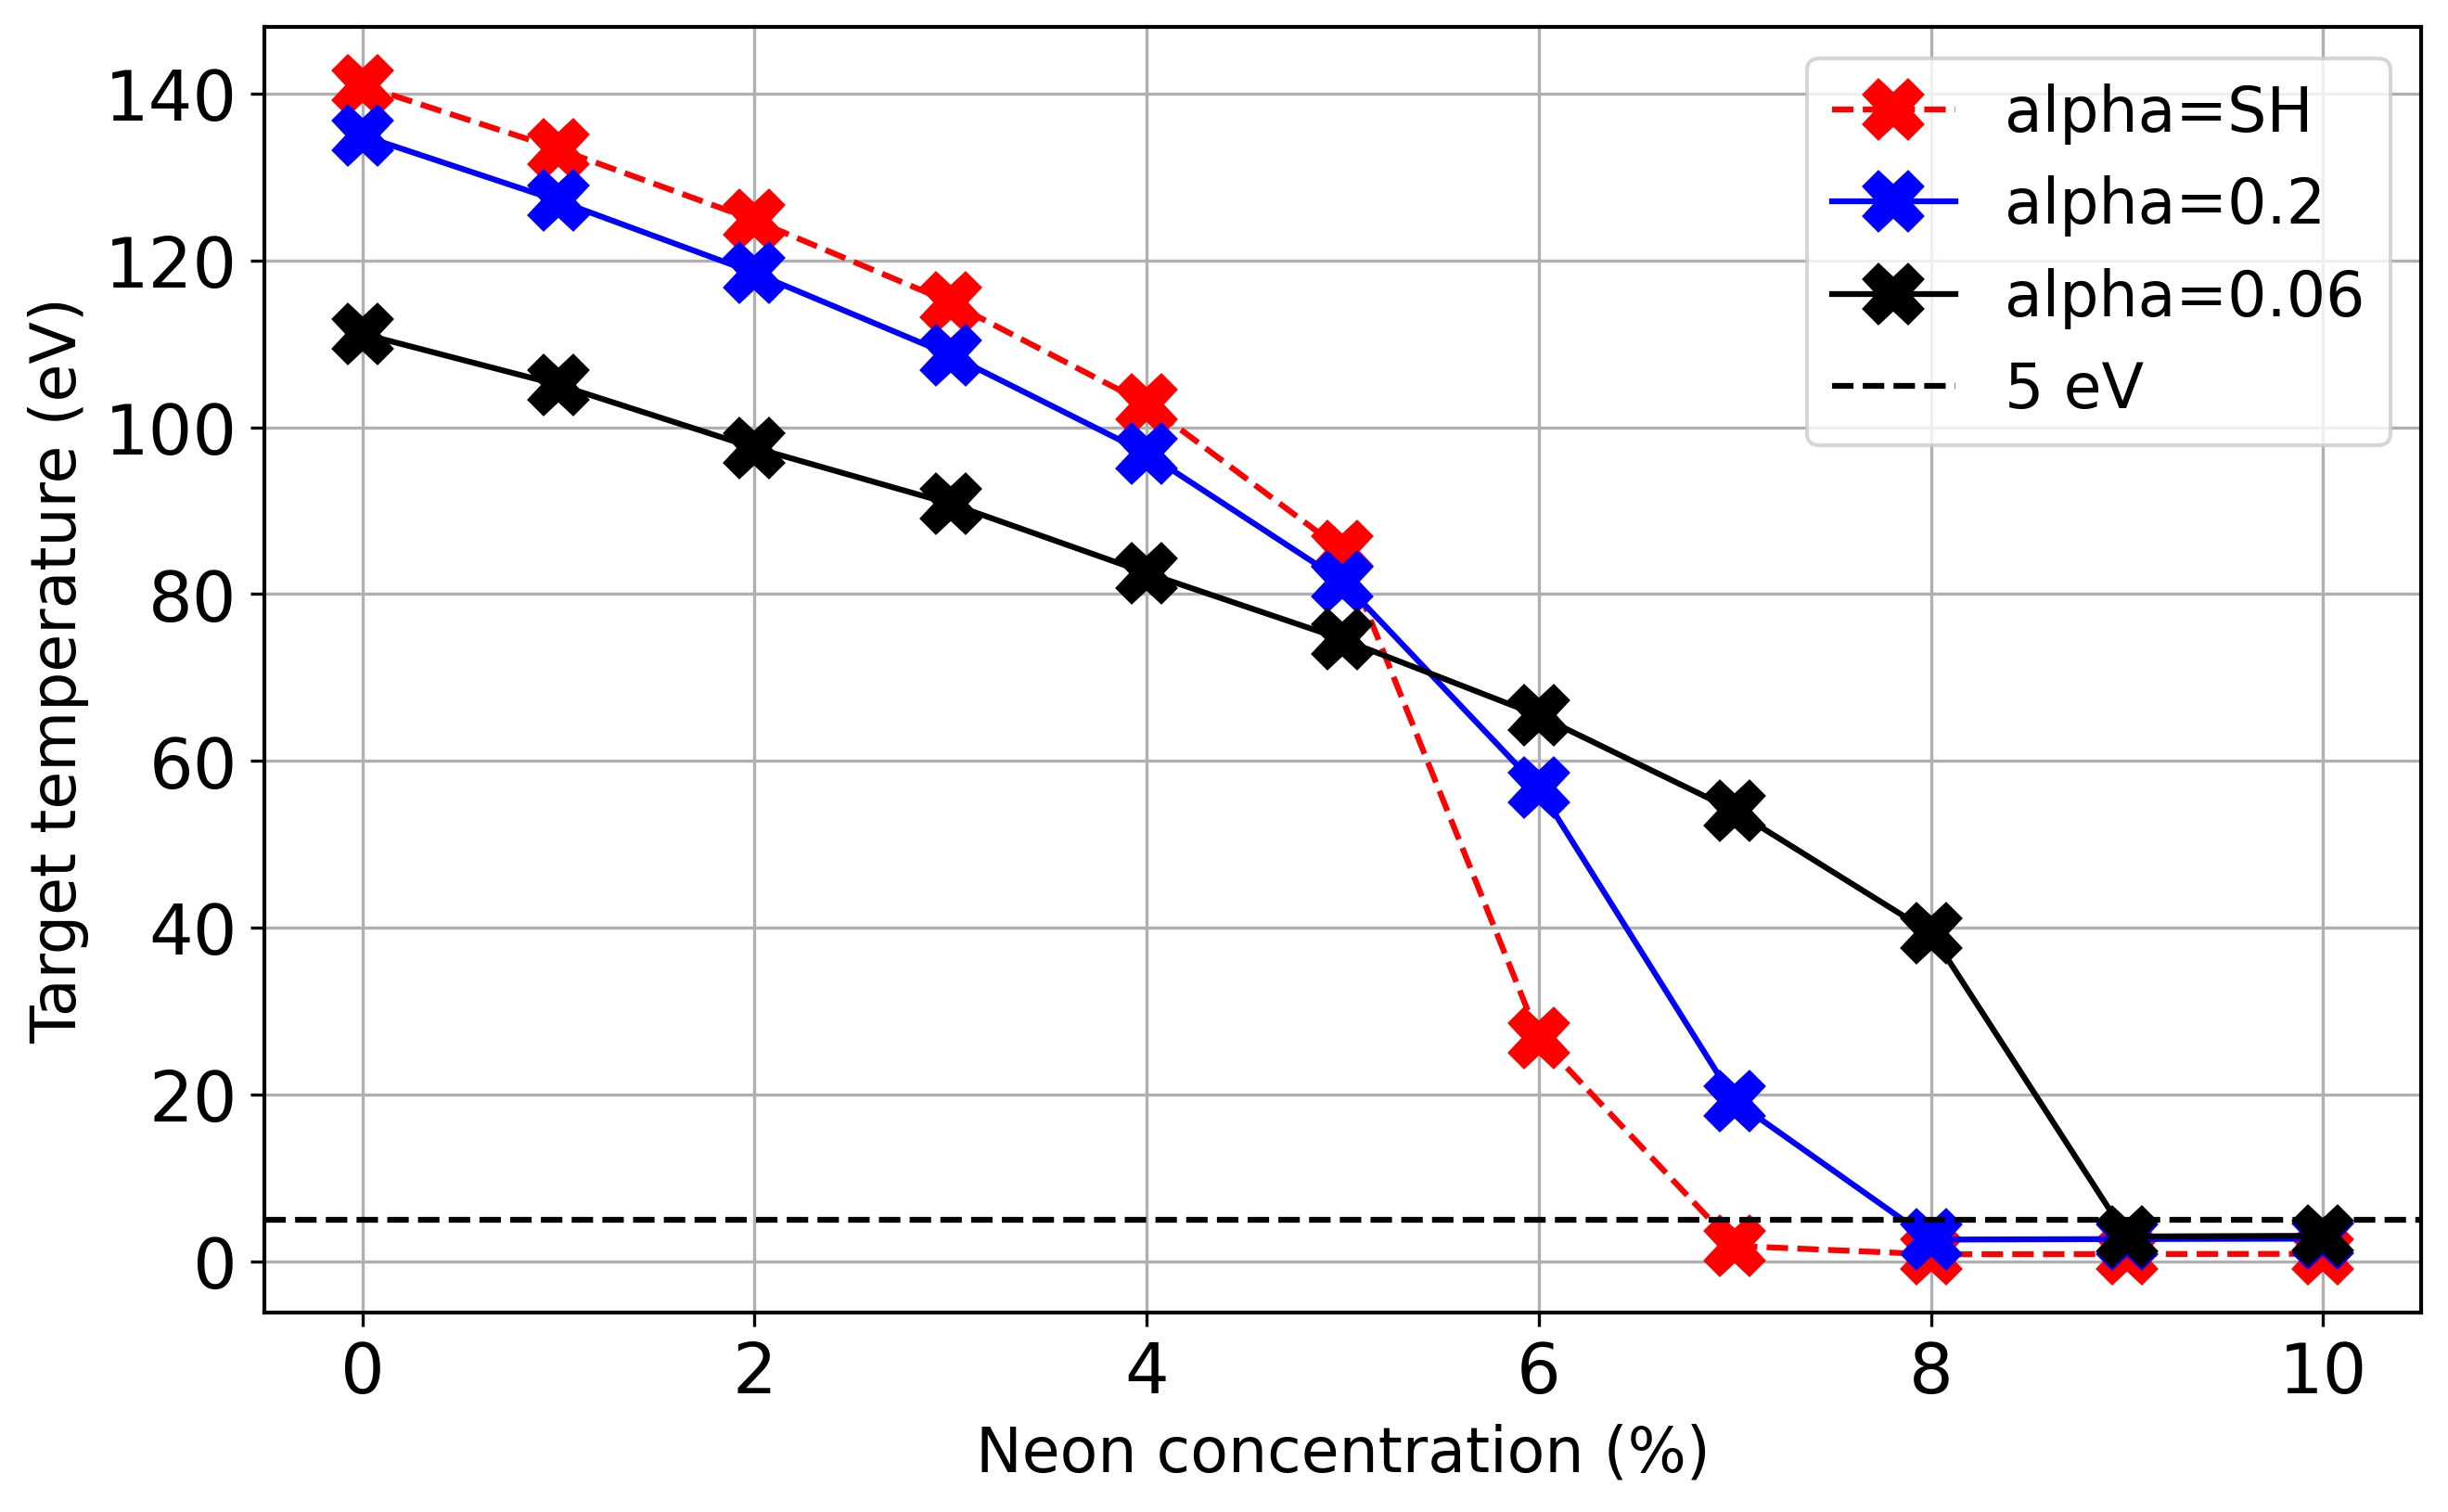

In [4]:
fig,ax = plt.subplots(1, 1, figsize=(10, 6), dpi=300)
# ax2 = ax.twinx()


neon_vals = np.array([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1])

for i in alpha_vals:
    target_temp_list = []
    neon_radiation_list = []
    if i == -1:
        linestyle = '--'
        color = 'red'
        label = 'SH'
    elif i == 0.2:
        linestyle = '-'
        color = 'blue'
        label = i
    elif i == 0.06:
        linestyle = '-'
        color = 'black'
        label = i
    elif i == 'snb':
        linestyle = ':'
        color = 'magenta'
        label = 'SNB'

    for j in neon_vals:
        target_temp = replace_guards(cs[f'alpha_{i}_neon_{j}'].ds.isel(t=-1)['Te'].values)[-1]
        target_temp_list.append(target_temp)
        neon_radiation = -1 * sum(replace_guards(cs[f'alpha_{i}_neon_{j}'].ds.isel(t=-1)['Rneon'].values) * replace_guards(cs[f'alpha_{i}_neon_{j}'].ds.isel(t=-1)['dv'].values))
        neon_radiation_list.append(neon_radiation)

    ax.plot(np.array(neon_vals)*100, target_temp_list, linestyle=linestyle, color=color, label=f'alpha={label}', markersize=markersize, marker = 'X')
    # ax2.plot(np.array(neon_vals)*100, neon_radiation_list, linestyle=linestyle, color=color, markersize=markersize, marker = 'o')

    
ax.axhline(5, color='black', linestyle='--', label='5 eV')
ax.set_xlabel('Neon concentration (%)')
ax.set_ylabel('Target temperature (eV)')
ax.legend()

